#NAME:SEBA SAUD

---
title: "Exercise: EDA on Penguins"
toc: true
format: 
  html:
    dir: ltr
  ipynb: default
---

Note: you can **Download** the notebook from the sidebar, where it says "**Jupyter**".

In this notebook exercise, we will conduct simple EDA steps on the popular penguins dataset.

### Load the dataset

The following will load the dataset automatically.

In [2]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import seaborn as sns

In [6]:
# You don't have to download the dataset
# the following will download it for you
df = sns.load_dataset('penguins')

Dataset source: https://github.com/allisonhorst/palmerpenguins

In [ ]:
df.shape

(333, 7)

# Step 1 Understand the Features

You can find information about this dataset here: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

**Question: in your own words**:

1. describe each feature
2. mention its type (numeric or categorical)
3. write its name in Arabic

Please use a Markdown cell to write your answer:

1. species  
- Description: Type of penguin  
- Type: Categorical  

2. island  
- Description: Island where the penguin lives  
- Type: Categorical  

3. bill_length_mm  
- Description: Length of the bill in millimeters  
- Type: Numerical  

4. bill_depth_mm  
- Description: Depth of the bill  
- Type: Numerical  

5. flipper_length_mm  
- Description: Length of the flipper  
- Type: Numerical  

6. body_mass_g  
- Description: Body mass in grams  
- Type: Numerical  

7. sex  
- Description: Gender of the penguin  
- Type: Categorical  

Hint: you can attach an image to illustrate what the features are.

<img src="https://github.com/allisonhorst/palmerpenguins/raw/main/man/figures/culmen_depth.png" width="400">

# Step 2

- Have a look at the columns and their values (`head`, `sample`, `tail`)
- Look at the technical information (`info`)

In [6]:
import pandas as pd
import seaborn as sns
df = sns.load_dataset("penguins")
print("HEAD:")
print(df.head())
print("\nSAMPLE:")
print(df.sample(5))
print("\nTAIL:")
print(df.tail())
print("\nINFO:")
print(df.info())

HEAD:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

SAMPLE:
       species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
97      Adelie      Dream            40.3           18.5              196.0   
194  Chinstrap      Dream            50.9           19.1              196.0   
133     Adelie      Dream            37.5           18.5              199.0   
158  Chinstrap      Dream            46.1           18.2              178.

# Step 3

1. Calculate count of missing values
1. Calculate the percentage of missing values
2. For each column, check and handle missing values. You may:
    2. fill with mean or median
    1. drop the rows
3. Check and handle duplicated rows
4. **If** you chose to drop missing values, how much data did you lose?

In [9]:
#. MISSING VALUES
print("Missing values count:")
print(df.isnull().sum())

#. PERCENTAGE
print("\nMissing percentage:")
print((df.isnull().sum() / len(df)) * 100)

#. PROSSICENG

#. MEDIAN
df['bill_length_mm'].fillna(df['bill_length_mm'].mean(), inplace=True)
df['bill_depth_mm'].fillna(df['bill_depth_mm'].mean(), inplace=True)
df['flipper_length_mm'].fillna(df['flipper_length_mm'].mean(), inplace=True)
df['body_mass_g'].fillna(df['body_mass_g'].mean(), inplace=True)

# MORE SHOWING
df['sex'].fillna(df['sex'].mode()[0], inplace=True)


# CHECKING
print("\nDuplicates:")
print(df.duplicated().sum())

 #DELETE
df.drop_duplicates(inplace=True)

# DATA AFTER CLEANING
print("\nShape after cleaning:")
print(df.shape)

Missing values count:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Missing percentage:
species              0.000000
island               0.000000
bill_length_mm       0.581395
bill_depth_mm        0.581395
flipper_length_mm    0.581395
body_mass_g          0.581395
sex                  3.197674
dtype: float64

Duplicates:
0

Shape after cleaning:
(344, 7)


C:\Users\HP\AppData\Local\Temp\ipykernel_6752\2275390183.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['bill_length_mm'].fillna(df['bill_length_mm'].mean(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_6752\2275390183.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through ch

# Step 4: Data types conversion

- We shall convert the string types to `category` to preserve memory
- numeric types can be stored in less precision: `float32`

In [10]:
mem_usage_before = df.memory_usage(deep=True)
print(mem_usage_before.sum())

67547


In [12]:
df['species'] = df['species'].astype('category')
df['island'] = df['island'].astype('category')
df['sex'] = df['sex'].astype('category')
print("\nData types after conversion:")
print(df.dtypes)    


Data types after conversion:
species              category
island               category
bill_length_mm        float64
bill_depth_mm         float64
flipper_length_mm     float64
body_mass_g           float64
sex                  category
dtype: object


In [14]:
df['bill_depth_mm'] = df['bill_depth_mm'].astype('float32')
df['bill_length_mm'] = df['bill_length_mm'].astype('float32')
df['flipper_length_mm'] = df['flipper_length_mm'].astype('float32')
df['body_mass_g'] = df['body_mass_g'].astype('float32')
print("\nData types after conversion:")
print(df.dtypes)    


Data types after conversion:
species              category
island               category
bill_length_mm        float32
bill_depth_mm         float32
flipper_length_mm     float32
body_mass_g           float32
sex                  category
dtype: object


Calculate memory saved after type conversion

In [15]:
mem_usage_after = df.memory_usage(deep=True)
print(mem_usage_after.sum())


7111


In [16]:
print('memory saved:', (mem_usage_before - mem_usage_after).sum() // 1024, 'KB')

memory saved: 59 KB


# Step 5: Detect inconsistency in categorical values

The categorical columns should be checked for any inconsistencies. For example. We look for lowercase, uppercase, or inconsistent use of codes (e.g., "M", "F") with non-codes (e.g., "Male", "Female")  in the `sex` column.

- hint: use `.unique()` to check the number of unique values in a column
- you can also use: `.value_counts()` to check the frequency of each value in a column

In [17]:
print("Species unique:")
print(df['species'].unique())
print("\nIsland unique:")
print(df['island'].unique())
print("\nSex unique:")
print(df['sex'].unique())
print("\nSex value counts:")
print(df['sex'].value_counts())

Species unique:
['Adelie', 'Chinstrap', 'Gentoo']
Categories (3, str): ['Adelie', 'Chinstrap', 'Gentoo']

Island unique:
['Torgersen', 'Biscoe', 'Dream']
Categories (3, str): ['Biscoe', 'Dream', 'Torgersen']

Sex unique:
['Male', 'Female', NaN]
Categories (2, str): ['Female', 'Male']

Sex value counts:
sex
Male      168
Female    165
Name: count, dtype: int64


# Step 6: Univariate Analysis

- Separate numerical from categorical columns (hint; use `df.select_dtypes()`)
- Look at the statistical information for each:
    - `df_num.describe().T`
    - `df_cat.describe().T`

In [18]:
df_num = df.select_dtypes(include=['float32', 'int'])
df_cat = df.select_dtypes(include=['category'])

print("Numerical summary:")
print(df_num.describe().T)

print("\nCategorical summary:")
print(df_cat.describe().T)

Numerical summary:
                   count         mean         std          min          25%  \
bill_length_mm     342.0    43.921932    5.459584    32.099998    39.224998   
bill_depth_mm      342.0    17.151171    1.974793    13.100000    15.600000   
flipper_length_mm  342.0   200.915207   14.061714   172.000000   190.000000   
body_mass_g        342.0  4201.754395  801.954529  2700.000000  3550.000000   

                           50%          75%          max  
bill_length_mm       44.450001    48.500000    59.599998  
bill_depth_mm        17.299999    18.700001    21.500000  
flipper_length_mm   197.000000   213.000000   231.000000  
body_mass_g        4050.000000  4750.000000  6300.000000  

Categorical summary:
        count unique     top freq
species   344      3  Adelie  152
island    344      3  Biscoe  168
sex       333      2    Male  168


Use charts to plot `value_counts()` categorical variables:

1. plot `species` using bar plot
1. plot `island` using pie chart
1. plot `sex` using horizontal bar plot

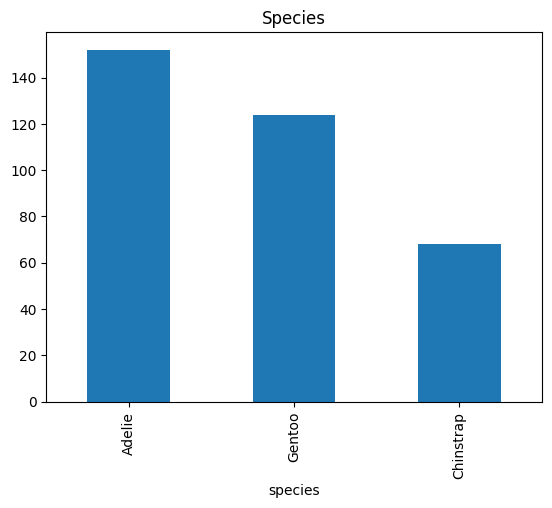

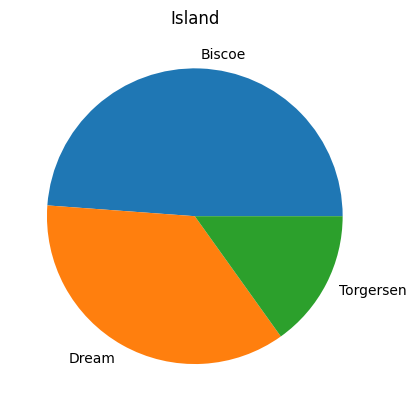

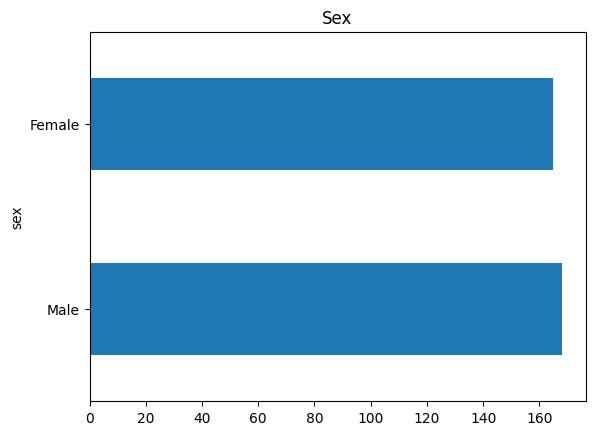

In [20]:
import matplotlib.pyplot as plt
df['species'].value_counts().plot(kind='bar', title='Species')
plt.show()
df['island'].value_counts().plot(kind='pie', title='Island')
plt.show()
df['sex'].value_counts().plot(kind='barh', title='Sex')
plt.show()

Plot numerical variables:

1. Boxplot: `bill_length_mm`
1. Histogram: `bill_depth_mm`
1. Boxplot: `flipper_length_mm`
1. Histogram: `body_mass_g`

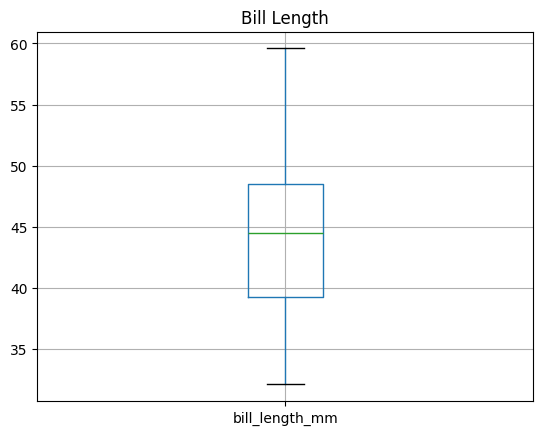

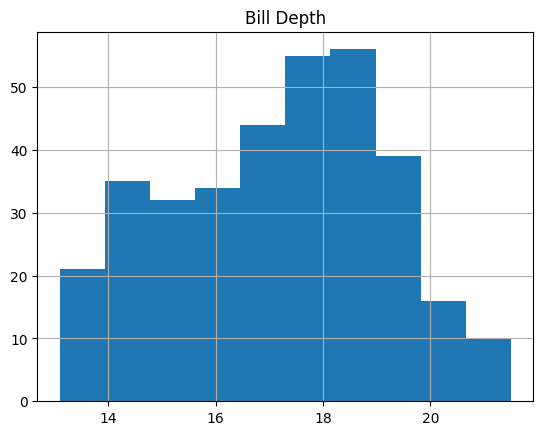

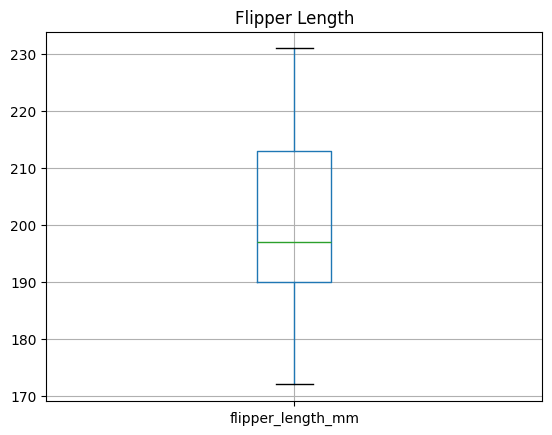

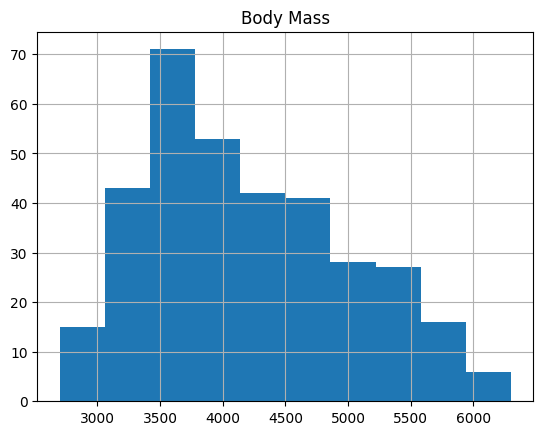

In [21]:
df.boxplot(column='bill_length_mm')
plt.title("Bill Length")
plt.show()
df['bill_depth_mm'].hist()
plt.title("Bill Depth")
plt.show()
df.boxplot(column='flipper_length_mm')
plt.title("Flipper Length")
plt.show()
df['body_mass_g'].hist()
plt.title("Body Mass")
plt.show()

# Step 7: Bivariate Analysis

## Correlation between numerical features

Let's find out if there is any correlation between numerical features.

- Hint: you can use the `df.corr()` to find the correlation matrix.
- Hint: you can use `sns.heatmap()` to plot the correlation matrix
- Hint: you can use `sns.pairplot()` to visualize relationships.

Correlation matrix:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.235053           0.656181   
bill_depth_mm           -0.235053       1.000000          -0.583851   
flipper_length_mm        0.656181      -0.583851           1.000000   
body_mass_g              0.595110      -0.471916           0.871202   

                   body_mass_g  
bill_length_mm        0.595110  
bill_depth_mm        -0.471916  
flipper_length_mm     0.871202  
body_mass_g           1.000000  


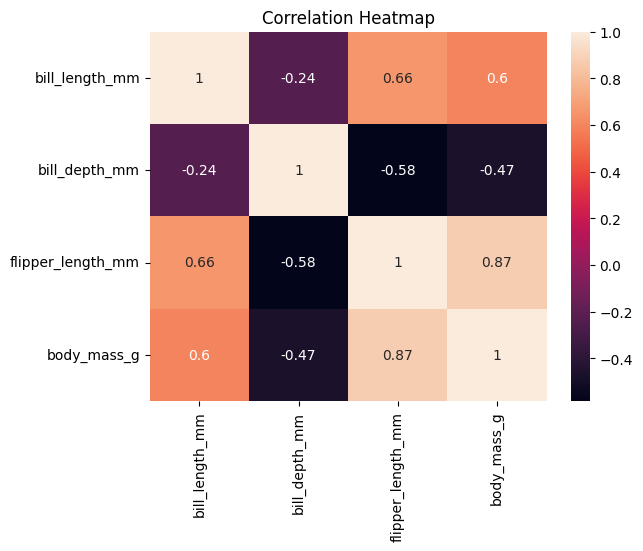

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df.corr(numeric_only=True)
print("Correlation matrix:")
print(corr)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()
sns.pairplot(df)
plt.show()

Question: Write down your observations based on the correlation heatmap.

**Observations:**

- There is a strong positive correlation between flipper_length_mm and body_mass_g.
- Some moderate relationships exist between bill measurements.
- Not all features are strongly correlated.

Looking at these distributions, how hard do you think it would be to classify the penguins only using `"culmen depth"` and `"culmen length"`?

Using culmen depth and culmen length alone would not perfectly classify penguins, because there is overlap between species.

# Feature Engineering

- We might try adding the feature `bill_size` which is the product of `bill_length` and `bill_depth` to see if it has any significance in the model.
- We might also try `bill_ratio` which is the ratio of `bill_length` to `bill_depth` to see if it has any significance in the model.

In [ ]:
# INSERT CODE HERE

Let's look at the correlation to see whether the newly created features are better.

1. Compute the correlation matrix
1. Select the `'body_mass_g'` column, sort it, and plot it using horizontal bar plot

In [ ]:
# INSERT CODE HERE
# This plots the correlation values for a specific column
# which is usually what we are interested in

# corr['body_mass_g'].sort_values().plot.barh()